# Cluster HFpEF Visualization

In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sn

from IPython.display import display

from preproc import get_hfpef_200, convert2np

In [2]:
no_clusters = 8
lbl_colname= ['Death', 'CV death', 'Major cardiac events']

## Get Data

In [3]:
data_df = get_hfpef_200()

In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   200 non-null    int64  
 1   Sex                   200 non-null    int64  
 2   Cr                    200 non-null    float64
 3   GFR                   200 non-null    float64
 4   CKD stage             200 non-null    int64  
 5   smoke                 200 non-null    float64
 6   BMI                   200 non-null    float64
 7   BSA                   200 non-null    float64
 8   DM                    200 non-null    int64  
 9   Insulin               200 non-null    int64  
 10  AF                    200 non-null    int64  
 11  SBP                   200 non-null    int64  
 12  DBP                   200 non-null    int64  
 13  MAP                   200 non-null    float64
 14  PP                    200 non-null    int64  
 15  1/2SBP                2

In [6]:
data_df.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,BSA,DM,Insulin,...,E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LVH,LAVI,LACI,LA diameter,LVEF
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,72.045000,1.680000,1.711100,52.293250,2.810000,0.105000,26.738830,1.632980,0.560000,0.215000,...,0.741571,17.300650,1.890100,0.648305,115.640950,2.640000,17.428481,3.211636,16.797793,61.434500
std,11.404529,0.467647,1.534721,25.188572,1.043718,0.307323,6.636857,0.228277,0.497633,0.411853,...,0.606755,8.602117,1.443655,0.388423,52.778994,1.896943,52.106319,3.988946,18.158083,8.420635
min,31.000000,1.000000,0.550000,2.000000,1.000000,0.000000,15.400000,1.120000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.000000,0.000000,0.000000
25%,65.000000,1.000000,0.887500,34.750000,2.000000,0.000000,22.200000,1.485000,0.000000,0.000000,...,0.500000,11.600000,0.000000,0.400000,86.725000,1.000000,0.000000,0.000000,3.700000,56.000000
50%,74.000000,2.000000,1.140000,54.000000,3.000000,0.000000,26.300000,1.600000,1.000000,0.000000,...,0.700000,16.300000,2.460000,0.555000,113.150000,2.500000,32.600000,2.479869,4.500000,61.000000
75%,80.000000,2.000000,1.792500,70.250000,3.000000,0.000000,29.925000,1.800000,1.000000,0.000000,...,1.000000,22.100000,3.002500,0.865000,141.305000,4.000000,48.425000,5.111374,37.692250,66.000000
max,97.000000,2.000000,10.000000,108.000000,5.000000,1.000000,55.900000,2.300000,1.000000,1.000000,...,4.100000,42.200000,4.550000,2.300000,356.600000,7.000000,140.800000,23.665480,59.919000,82.900000


## 1. All Features

In [7]:
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture

from sklearn.pipeline import make_pipeline

from utils import get_score, score_columns, plot_data

import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
X, y, feature_list = convert2np(data_df, lbl_colname)

In [9]:
def get_km_pred(k, X):
    km = KMeans(n_clusters=k, random_state=0)
    return km.fit_predict(X)

def get_sc_pred(k, X):
    sc = SpectralClustering(n_clusters=k, eigen_solver='arpack', affinity="nearest_neighbors", random_state=0)
    return sc.fit_predict(X)

def get_gm_pred(k, X):
    gm = GaussianMixture(n_components=k, random_state=0, init_params='kmeans').fit(X)
    return gm.predict(X)

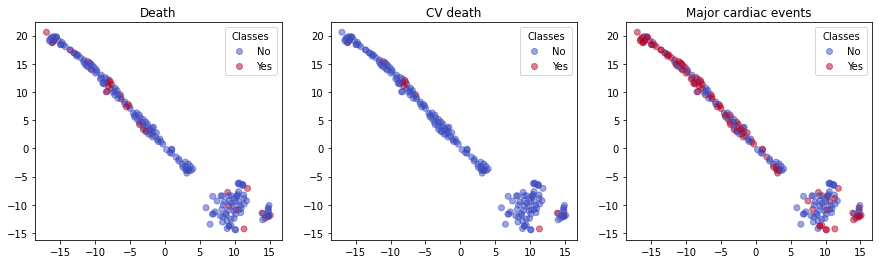

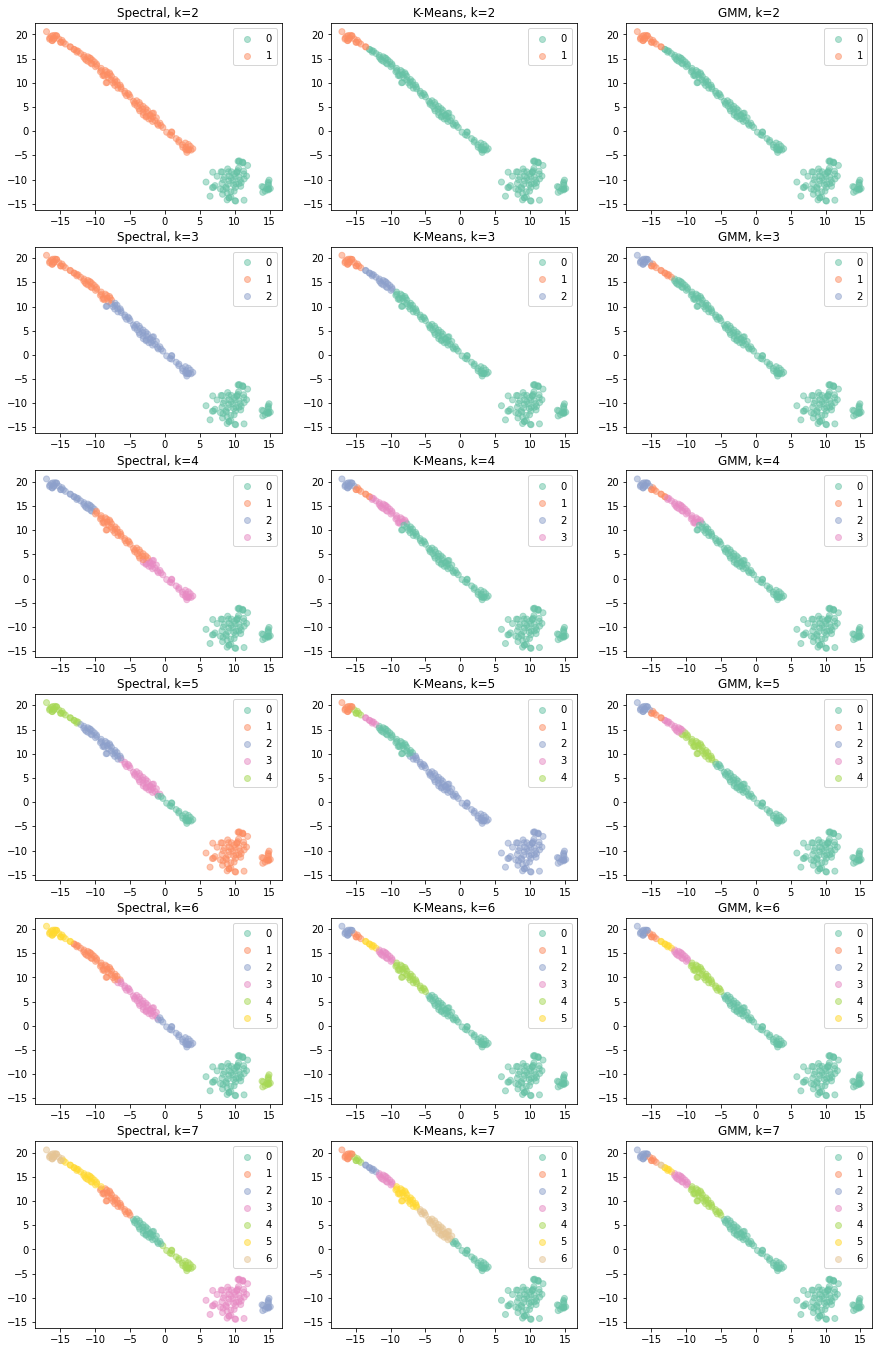

In [10]:
plot_data(X, y, no_clusters, {"Spectral":get_sc_pred, "K-Means":get_km_pred, "GMM":get_gm_pred}, lbl_colname)

## 2. Selected Feature

In [11]:
X, y, feature_list = convert2np(data_df, lbl_colname, selected_feat=True)

C:\Users\HP\miniconda3\lib\site-packages\sklearn\manifold\_spectral_embedding.py:245: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn("Graph is not fully connected, spectral embedding"
C:\Users\HP\miniconda3\lib\site-packages\sklearn\manifold\_spectral_embedding.py:245: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn("Graph is not fully connected, spectral embedding"
C:\Users\HP\miniconda3\lib\site-packages\sklearn\manifold\_spectral_embedding.py:245: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn("Graph is not fully connected, spectral embedding"
C:\Users\HP\miniconda3\lib\site-packages\sklearn\manifold\_spectral_embedding.py:245: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn("Graph is not fully connected, spectral embedding"
C:\Users\HP\miniconda3\lib\site-pack

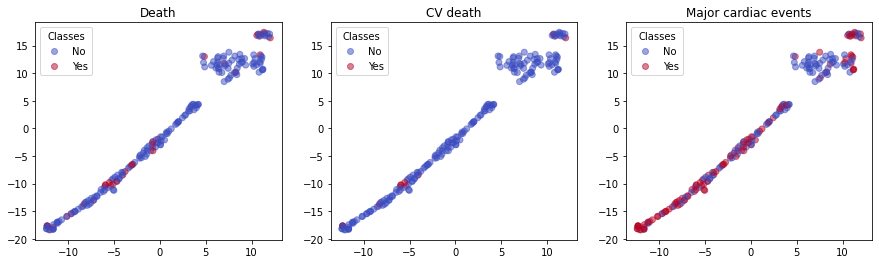

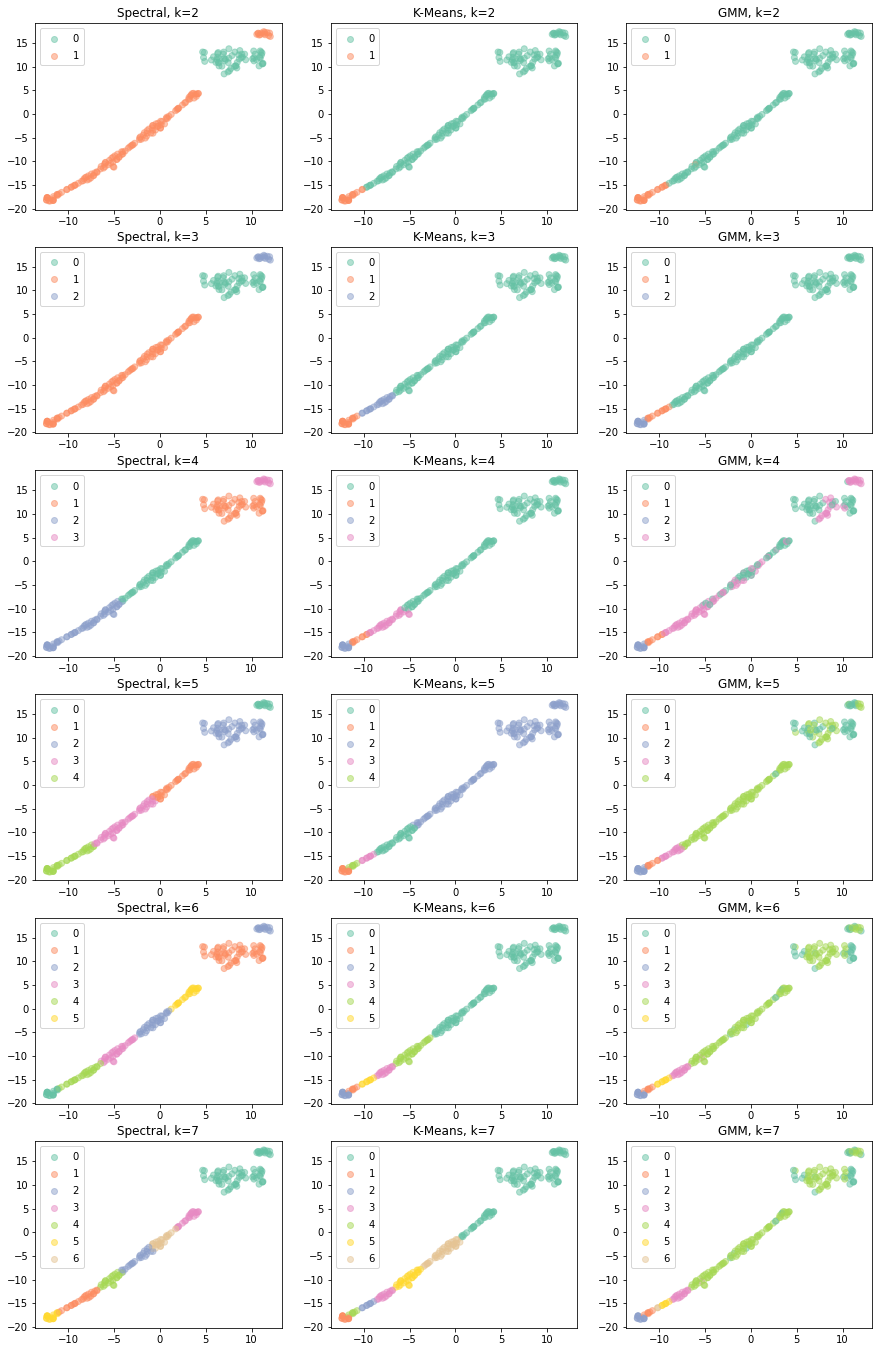

In [12]:
plot_data(X, y, no_clusters, {"Spectral":get_sc_pred, "K-Means":get_km_pred, "GMM":get_gm_pred}, lbl_colname)

## Get Cleaned Data

In [13]:
data_df_nomiss = get_hfpef_200(nomiss=True)

In [15]:
data_df_nomiss.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 80 entries, 1 to 199
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   80 non-null     int64  
 1   Sex                   80 non-null     int64  
 2   Cr                    80 non-null     float64
 3   GFR                   80 non-null     float64
 4   CKD stage             80 non-null     int64  
 5   smoke                 80 non-null     float64
 6   BMI                   80 non-null     float64
 7   BSA                   80 non-null     float64
 8   DM                    80 non-null     int64  
 9   Insulin               80 non-null     int64  
 10  AF                    80 non-null     int64  
 11  SBP                   80 non-null     int64  
 12  DBP                   80 non-null     int64  
 13  MAP                   80 non-null     float64
 14  PP                    80 non-null     int64  
 15  1/2SBP                80

In [16]:
data_df_nomiss.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,BSA,DM,Insulin,...,E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LVH,LAVI,LACI,LA diameter,LVEF
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.00000,80.000000,...,80.000000,80.000000,80.000000,80.000000,80.0000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,72.212500,1.700000,1.662125,54.480500,2.737500,0.062500,26.156735,1.609162,0.58750,0.250000,...,0.961500,19.038625,1.902625,0.672113,121.0900,2.925000,24.565556,5.152243,18.100662,62.260000
std,11.623518,0.461149,1.486146,27.486385,1.110864,0.243589,6.292129,0.198474,0.49539,0.435745,...,0.476238,8.867438,1.422817,0.376618,45.8851,1.826493,45.879166,4.377082,17.768611,7.273406
min,31.000000,1.000000,0.640000,2.000000,1.000000,0.000000,15.400000,1.120000,0.00000,0.000000,...,0.400000,4.290000,0.000000,0.230000,53.8000,0.000000,-95.629630,0.000000,2.100000,50.000000
25%,65.000000,1.000000,0.855000,30.250000,2.000000,0.000000,21.825000,1.465000,0.00000,0.000000,...,0.600000,12.475000,0.000000,0.420000,90.2000,1.000000,23.425000,2.556917,3.975000,57.825000
50%,74.500000,2.000000,1.115000,57.500000,3.000000,0.000000,25.450000,1.600000,1.00000,0.000000,...,0.900000,17.500000,2.405000,0.550000,113.8500,3.000000,33.850000,4.403986,4.500000,61.250000
75%,79.000000,2.000000,1.900000,77.250000,3.250000,0.000000,29.825000,1.705000,1.00000,0.250000,...,1.125000,23.350000,3.050000,0.860000,135.4000,4.000000,47.750000,6.716609,37.069000,66.250000
max,92.000000,2.000000,10.000000,108.000000,5.000000,1.000000,44.400000,2.000000,1.00000,1.000000,...,3.200000,42.200000,4.550000,2.300000,356.6000,7.000000,107.700000,23.665480,59.919000,80.000000


## 3. Cleaned Data

In [17]:
X, y, feature_list = convert2np(data_df_nomiss, lbl_colname, selected_feat=True)

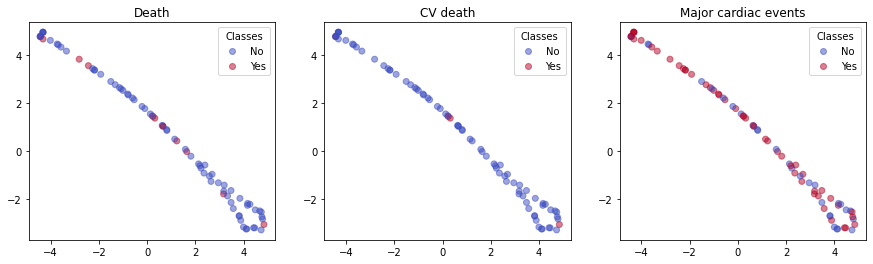

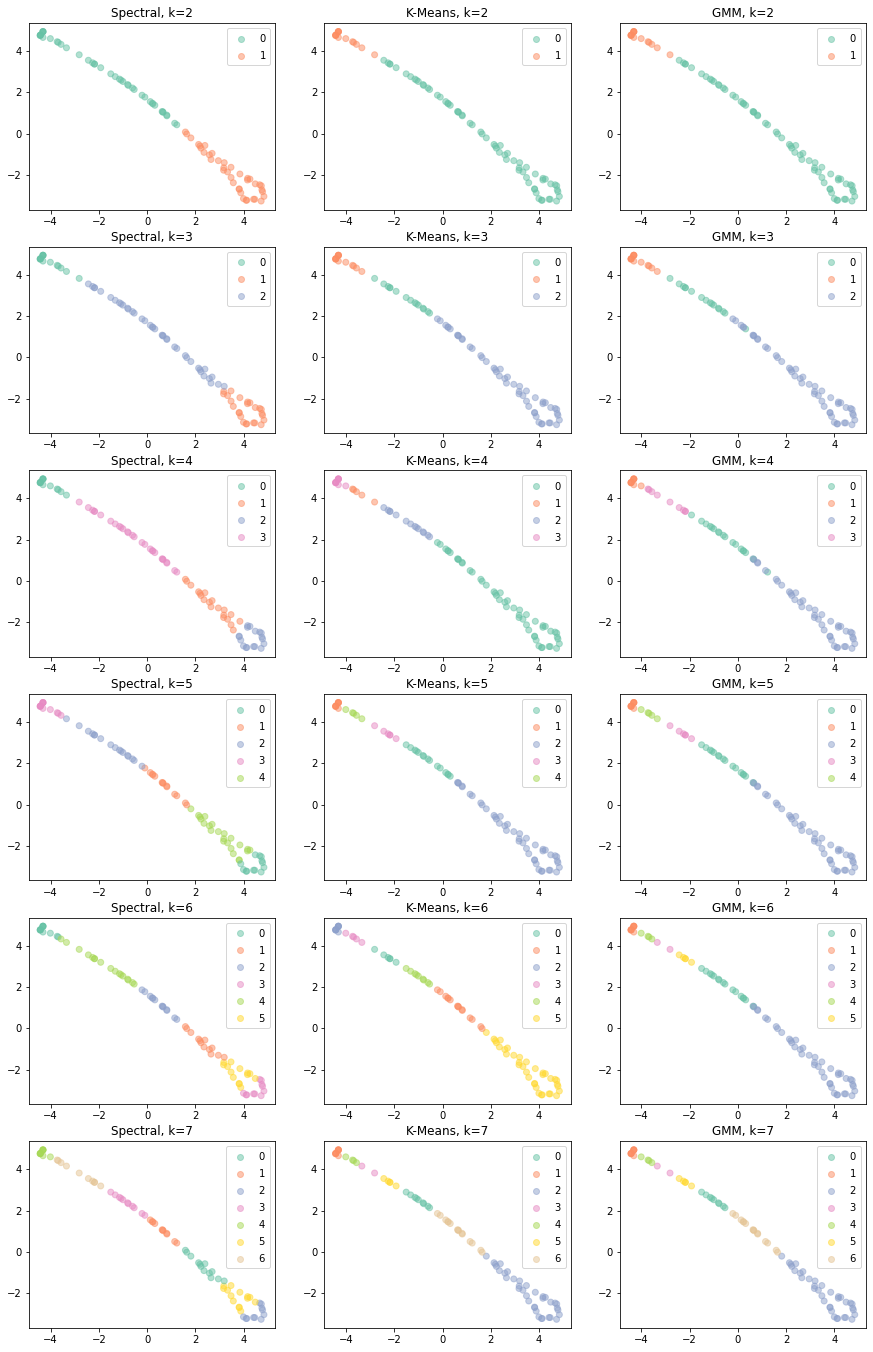

In [18]:
plot_data(X, y, no_clusters, {"Spectral":get_sc_pred, "K-Means":get_km_pred, "GMM":get_gm_pred}, lbl_colname)